# 개요

- 방향 $p$ 를 정하고 보폭 $\alpha$ 를 1차원 탐색으로 따로 정하는 계열을 Rosenbrock 골짜기에서 비교한다.
- $H$ 를 무엇으로 두느냐가 반복 횟수를 세 자릿수 바꾼다는 것을 직접 센다.

# 1. Line Search

- `Gradient Descent` $H = I$
	- 가장 단순. 수렴 속도가 조건수에 그대로 지배된다
- `Newton` $H = \nabla^{2}F$
	- 2차 수렴. 대신 Hessian이 필요하고 양정부호가 아닐 수 있다
- `BFGS` $H \approx$ 곡률 누적
	- Hessian 없이 2차에 가까운 속도

---
## 1.1. 공통 골격

매 반복 방향과 보폭을 정해 갱신한다.

$$ x_{k+1} = x_{k} + \alpha_{k} p_{k}, \qquad p_{k} = -H_{k}^{-1}g_{k} $$

- $g_k = \nabla F(x_k)$
- $H_k$: 알고리즘마다 다른 2차항. $H = I$ 면 $p = -g$ 로 최급강하가 된다

$p$ 가 내리막이려면 $g^{T}p < 0$ 이어야 한다. $H$ 가 양정부호면 자동으로 보장된다.

---
## 1.2. Armijo 조건

보폭을 아무렇게나 정하면 발산한다. 최소한 **충분히 감소**해야 한다.

$$
\boxed{
F(x + \alpha p) \le F(x) + c_{1}\,\alpha\, g^{T}p, \qquad c_{1} = 10^{-4}
}
$$

우변은 접선을 $c_1$ 만큼 눕힌 직선이다. $\alpha$ 를 1부터 절반씩 줄이며 이 선 아래로 들어오는
첫 값을 쓰는 것이 `backtracking`이고, 이 한 줄이 line search의 전부다.

즉,

> 한 걸음 갔을 때 기울기가 약속한 만큼은 실제로 내려갔는가

---
## 1.3. Newton과 BFGS

Newton은 $H$ 에 진짜 Hessian을 쓴다. 문제는 최소점에서 멀면 $\nabla^{2}F$ 가 양정부호가 아니라
$p$ 가 **오르막**을 가리킬 수 있다는 것이다. 그때는 $p = -g$ 로 물러선다.

BFGS는 Hessian 대신 $H^{-1}$ 의 근사 $B_{k}$ 를 연속한 두 점의 기울기 차이로 누적한다.

$$ s_{k} = x_{k+1} - x_{k}, \qquad y_{k} = g_{k+1} - g_{k}, \qquad \varrho_{k} = \frac{1}{y_{k}^{T}s_{k}} $$

$$
\boxed{
B_{k+1} = \left(I - \varrho_{k}s_{k}y_{k}^{T}\right)B_{k}\left(I - \varrho_{k}y_{k}s_{k}^{T}\right) + \varrho_{k}s_{k}s_{k}^{T}
}
$$

- $B_k$: **역** Hessian 근사. 그래서 $p = -B_k g$ 이고 선형 시스템을 풀 필요가 없다

$y^{T}s > 0$ 일 때만 갱신한다. 이 조건이 $B_{k}$ 의 양정부호를 지키고, Wolfe curvature 조건이
보장하려는 것이 정확히 이것이다.

---
## 1.4. 전체 파이프라인

$$ \boxed{ g \rightarrow p = -H^{-1}g \rightarrow \alpha \;(\text{Armijo}) \rightarrow x + \alpha p \rightarrow B\ \text{갱신} } $$

```txt
            x_k
             |
        g = grad F
             |
   +---------+----------+-----------+
   |         |          |           |
  p=-g   p=-H^-1 g   p=-B g      (방향)
   GD      Newton      BFGS
   |         |          |
   +---------+----------+
             |
     backtracking Armijo     (보폭)
             |
          x_{k+1}
```

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# numpy 2.x + Apple Accelerate 조합에서 matmul 이 부동소수점 상태 플래그를 잘못 남긴다.
# 결과값은 전부 정상이라(직접 대조해 확인했다) 이 조합에서만 나오는 잡음만 끈다.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)


def pick_korean_font():
    """한글과 수학 마이너스(U+2212)를 **둘 다** 가진 폰트를 우선 고른다.

    로그 축 눈금은 $\mathdefault{10^{-13}}$ 로 그려지는데, mathtext 는 여기서 font.family 를
    쓴다. AppleGothic 계열에는 U+2212 가 없어서 지수의 마이너스가 네모로 깨진다 —
    한글은 멀쩡해서 알아채기 어렵다.
    """
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ("Arial Unicode MS", "Noto Sans CJK KR", "NanumGothic",
                  "Malgun Gothic", "Apple SD Gothic Neo", "AppleGothic")
    fallback = None
    for name in candidates:
        if name not in available:
            continue
        fallback = fallback or name
        try:
            path = font_manager.findfont(font_manager.FontProperties(family=name),
                                         fallback_to_default=False)
            if font_manager.get_font(path).get_char_index(0x2212):
                return name, True
        except Exception:
            continue
    return fallback, False


_font, _has_minus = pick_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
    plt.rcParams["axes.unicode_minus"] = _has_minus   # 없으면 ASCII 하이픈으로 대체
    plt.rcParams["mathtext.fontset"] = "dejavusans"
print(f"font: {_font}  (U+2212 보유: {_has_minus})")

font: Arial Unicode MS  (U+2212 보유: True)


## 0. 샘플 데이터 생성하기

- Rosenbrock $f(x) = (1-x_0)^2 + 100(x_1 - x_0^2)^2$. 최소점은 $(1, 1)$, $f = 0$ 이다.
- 초기값 $(-1.2, 1.0)$ 은 이 함수의 표준 시작점이다. 골짜기 바깥이라 할 일이 남아 있다.

In [2]:
import importlib
import problems
importlib.reload(problems)                 # 커널을 재시작하지 않아도 최신 버전을 반영
from problems import *

x_star = np.array([1.0, 1.0])              # 참값 (해석적으로 안다)
x_init = np.array([-1.2, 1.0])             # 표준 시작점

print("f(x_init) = %.4f" % rosenbrock(x_init))
print("f(x_star) = %.4f" % rosenbrock(x_star))
print("||x_init - x_star|| = %.4f" % np.linalg.norm(x_init - x_star))
print("cond(Hessian at x_star) = %.1f  <- 이 값이 GD 를 죽인다"
      % np.linalg.cond(rosenbrock_hess(x_star)))

f(x_init) = 24.2000
f(x_star) = 0.0000
||x_init - x_star|| = 2.2000
cond(Hessian at x_star) = 2508.0  <- 이 값이 GD 를 죽인다


# 1. 데이터 시각화

바나나 모양 골짜기를 먼저 본다. 최소점은 길고 평평한 계곡의 끝에 있다.

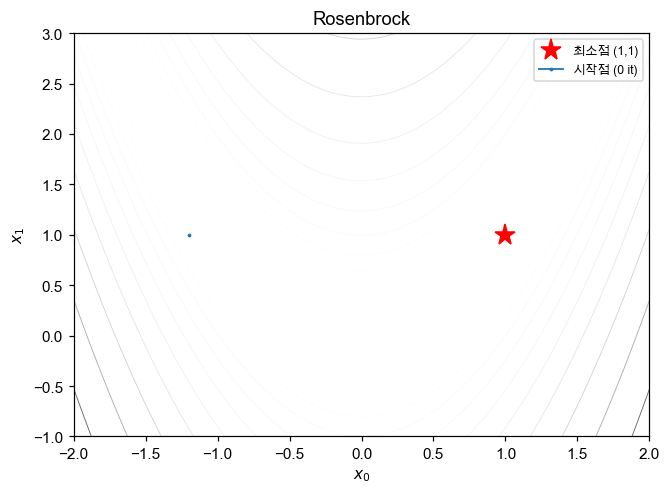

In [3]:
def show_contour(paths=None, labels=None, title="Rosenbrock"):
    """등고선 + 경로. 경로를 겹쳐 그리려고 함수로 뺀다 (before/after 를 같은 축에서 본다)."""
    gx, gy = np.meshgrid(np.linspace(-2.0, 2.0, 400), np.linspace(-1.0, 3.0, 400))
    gz = (1 - gx) ** 2 + 100 * (gy - gx ** 2) ** 2      # (400, 400)

    plt.figure(figsize=(6.2, 4.6))
    plt.contour(gx, gy, gz, levels=np.logspace(-1, 3.5, 25), cmap="Greys", linewidths=0.6)
    plt.plot(1, 1, "r*", ms=14, label="최소점 (1,1)")

    for path, label in zip(paths or [], labels or []):
        path = np.asarray(path)
        plt.plot(path[:, 0], path[:, 1], ".-", lw=1.2, ms=3, label=f"{label} ({len(path)-1} it)")

    plt.xlabel("$x_0$"); plt.ylabel("$x_1$"); plt.title(title)
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()


show_contour([[x_init]], ["시작점"])

# 2. Line Search 알고리즘

In [4]:
# 1. Armijo backtracking - F(x+ap) <= F(x) + c1 a g^T p
def backtracking(f, x, p, g, alpha=1.0, c1=1e-4, shrink=0.5, max_try=60):
    """조건을 만족하는 첫 alpha 를 돌려준다.

    max_try 를 다 쓰면 그 자리에서 멈춘다 — 무한루프보다 정직한 실패가 낫다.
    """
    f0 = f(x)
    slope = g @ p                                    # 음수여야 내리막이다
    for _ in range(max_try):
        if f(x + alpha * p) <= f0 + c1 * alpha * slope:
            return alpha
        alpha *= shrink
    return alpha

In [5]:
# 2. 방향 - p = -H^-1 g  (H 를 무엇으로 두느냐가 알고리즘을 가른다)
def direction(kind, x, g, B):
    """GD: H=I, Newton: H=hess, BFGS: B 는 역 Hessian 근사라 곱하기만 한다."""
    if kind == "GD":
        return -g
    if kind == "Newton":
        H = rosenbrock_hess(x)                       # (2, 2)
        try:
            p = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            return -g                                # 특이하면 최급강하로 물러선다
        return p if g @ p < 0 else -g                # 오르막이면 버린다
    return -B @ g

In [6]:
# 3. BFGS 갱신 - B <- (I - rho s y^T) B (I - rho y s^T) + rho s s^T
def bfgs_update(B, s, y):
    """y^T s > 0 일 때만 갱신한다. 이 조건이 B 의 양정부호를 지킨다."""
    sy = y @ s
    if sy <= 1e-12:
        return B                                     # 곡률 조건 위반 -> 건너뛴다
    rho = 1.0 / sy
    I = np.eye(len(s))
    return (I - rho * np.outer(s, y)) @ B @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)

## 2.1. 메인 루프

번호 주석이 1.4절 파이프라인 박스와 그대로 대응한다. GD는 수만 번을 돌 수 있으므로
상한을 크게 잡되, 그 상한 자체가 결과의 일부다.

In [7]:
tol = 1e-8
max_iter = 50000
results = {}

for kind in ("GD", "Newton", "BFGS"):
    x = x_init.copy()
    B = np.eye(2)                                    # BFGS 만 쓴다
    path, fhist = [x.copy()], [rosenbrock(x)]

    for it in range(1, max_iter + 1):
        # 1. gradient
        g = rosenbrock_grad(x)
        if np.linalg.norm(g) < tol:
            break
        # 2. 방향
        p = direction(kind, x, g, B)
        # 3. 보폭
        alpha = backtracking(rosenbrock, x, p, g)
        # 4. 갱신
        x_new = x + alpha * p
        # 5. BFGS 곡률 누적
        if kind == "BFGS":
            B = bfgs_update(B, x_new - x, rosenbrock_grad(x_new) - g)
        x = x_new
        path.append(x.copy()); fhist.append(rosenbrock(x))

    results[kind] = {"x": x, "iters": it, "path": np.array(path), "fhist": np.array(fhist)}
    print(f"{kind:7s} iters={it:6d}  f={rosenbrock(x):.3e}  "
          f"|x-x*|={np.linalg.norm(x - x_star):.3e}")

GD      iters= 19436  f=6.107e-17  |x-x*|=1.748e-08
Newton  iters=    22  f=3.744e-21  |x-x*|=1.351e-10
BFGS    iters=    36  f=4.251e-21  |x-x*|=1.353e-10


# 3. 검증

참값 $(1,1)$ 을 알고 있으므로 "수렴했다"가 아니라 "맞게 수렴했다"를 잰다.

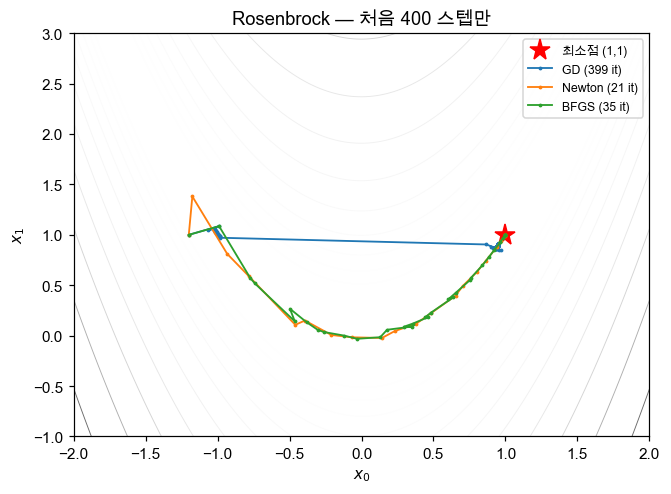

In [8]:
# 경로를 같은 등고선 위에 겹친다 - 축이 같아야 비교가 된다
show_contour([results[k]["path"][:400] for k in results],
             list(results),
             title="Rosenbrock — 처음 400 스텝만")

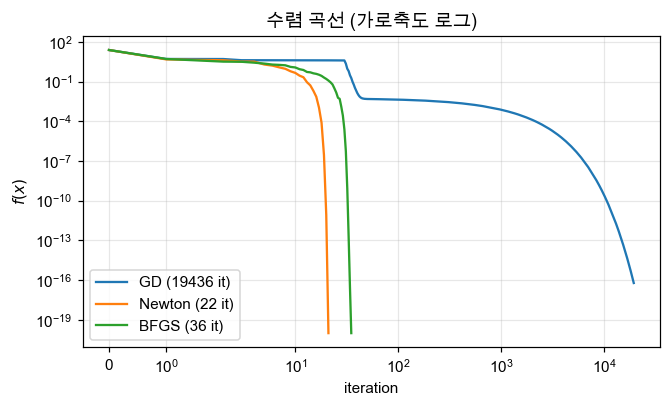

반복 횟수 비
  GD       19436  (  883.5 x Newton)
  Newton      22  (    1.0 x Newton)
  BFGS        36  (    1.6 x Newton)


In [9]:
plt.figure(figsize=(6.2, 3.8))
for kind, res in results.items():
    plt.semilogy(np.maximum(res["fhist"], 1e-20), label=f"{kind} ({res['iters']} it)")
plt.xlabel("iteration"); plt.ylabel("$f(x)$")
plt.xscale("symlog"); plt.title("수렴 곡선 (가로축도 로그)")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

print("반복 횟수 비")
base = results["Newton"]["iters"]
for kind, res in results.items():
    print(f"  {kind:7s} {res['iters']:6d}  ({res['iters'] / base:7.1f} x Newton)")

## 3.1. 곡률 조건은 line search가 지켜준다

BFGS가 요구하는 것은 $y^{T}s > 0$ 이다. 이걸 어기면 $B$ 가 양정부호를 잃는다.

직접 재 보면 **Armijo를 쓰는 동안에는 이 조건이 한 번도 걸리지 않는다.** 그게 우연이 아니라,
충분감소 조건이 곡률 조건의 역할을 대신 해주기 때문이다. line search를 빼고 $\alpha = 1$ 로
고정하면 그때부터 위반이 나타난다.

In [10]:
# line search 유무에 따라 y^T s 조건이 걸리는 횟수를 센다
for use_ls in (True, False):
    x, B = x_init.copy(), np.eye(2)
    violations = 0

    for it in range(1, 3001):
        g = rosenbrock_grad(x)
        if not np.all(np.isfinite(g)) or np.linalg.norm(g) < tol:
            break
        p = -B @ g
        alpha = backtracking(rosenbrock, x, p, g) if use_ls else 1.0
        x_new = x + alpha * p

        s, y = x_new - x, rosenbrock_grad(x_new) - g
        if y @ s <= 0:
            violations += 1                          # 갱신을 건너뛴다 (bfgs_update 와 같은 규칙)
        else:
            B = bfgs_update(B, s, y)
        x = x_new
        if not np.all(np.isfinite(x)):
            break

    label = "Armijo" if use_ls else "alpha=1 고정"
    print(f"{label:14s} iters={it:5d}  y^Ts<=0 위반 {violations:3d}회  f={rosenbrock(x):.3e}")

Armijo         iters=   36  y^Ts<=0 위반   0회  f=4.251e-21
alpha=1 고정     iters=   99  y^Ts<=0 위반   2회  f=1.640e-25


## 3.2. 한계

- Armijo만 썼고 Wolfe curvature 조건은 line search에 넣지 않았다. BFGS의 `y^Ts > 0` 검사가
  같은 역할을 대신하지만, 엄밀히는 strong Wolfe를 만족하는 $\alpha$ 를 찾아야 한다.
- Newton은 Hessian을 해석적으로 받아 썼다. 실제 문제에서 이걸 쓸 수 없다는 점이 `03`의 Gauss-Newton으로 이어진다.
- GD의 반복 횟수는 `tol` 에 민감하다. $10^{-8}$ 이 아니라 $10^{-6}$ 이면 훨씬 줄어든다 —
  절대값이 아니라 **자릿수 차이**만 읽어야 한다.